# Civilizational Indicators: Internal & External Order

Beyond financial metrics — tracking the health of institutions, social cohesion,
fiscal sustainability, and geopolitical position. These move slowly but are the
forces that ultimately drive big cycle transitions.

In [1]:
import sys
sys.path.insert(0, '..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from src.data_fetcher import load_series, load_config
from src import indicators

plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['figure.dpi'] = 100

RECESSIONS = [
    ('1973-11-01', '1975-03-01'),
    ('1980-01-01', '1980-07-01'),
    ('1981-07-01', '1982-11-01'),
    ('1990-07-01', '1991-03-01'),
    ('2001-03-01', '2001-11-01'),
    ('2007-12-01', '2009-06-01'),
    ('2020-02-01', '2020-04-01'),
]

def add_recessions(ax):
    for start, end in RECESSIONS:
        ax.axvspan(pd.Timestamp(start), pd.Timestamp(end), alpha=0.12, color='gray')

# Key events for annotation
EVENTS = {
    '1980': 'Reagan elected',
    '1989': 'Berlin Wall falls',
    '2001-09': '9/11',
    '2008-09': 'Lehman collapse',
    '2016-11': 'Trump elected',
    '2020-03': 'COVID lockdowns',
}

print('Loaded.')

Loaded.


## 1. Wealth Inequality: The Widening Gap

The divergence between top 1% and bottom 50% wealth shares is one of the clearest
signals of internal order stress. Historically, extreme inequality precedes populism,
institutional breakdown, and sometimes revolution.

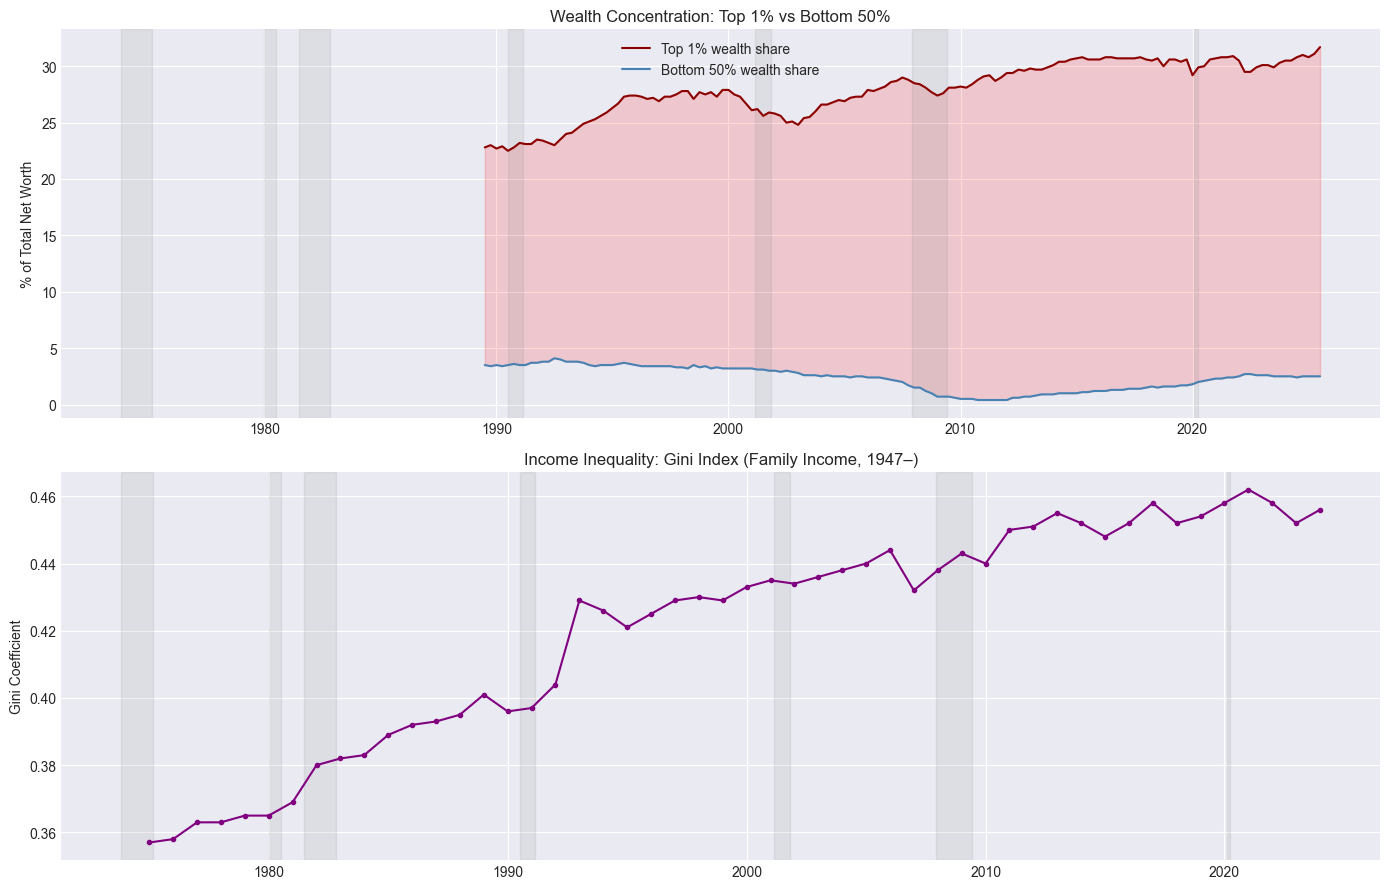


Top 1% wealth share: 22.8% (1989) → 31.7% (latest)
Bottom 50% wealth share: 3.5% (1989) → 2.5% (latest)
Gini: 0.357 (1947) → 0.456 (latest)


In [2]:
top1 = load_series('fred', 'WFRBST01134').squeeze()
bottom50 = load_series('fred', 'WFRBSB50215').squeeze()
gini = load_series('fred', 'GINIALLRF').squeeze()

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 9))

# Wealth shares
ax1.plot(top1.index, top1, color='darkred', linewidth=1.5, label='Top 1% wealth share')
ax1.plot(bottom50.index, bottom50, color='steelblue', linewidth=1.5, label='Bottom 50% wealth share')
ax1.fill_between(top1.index, top1, bottom50, alpha=0.15, color='red')
add_recessions(ax1)
ax1.set_ylabel('% of Total Net Worth')
ax1.set_title('Wealth Concentration: Top 1% vs Bottom 50%')
ax1.legend()

# Gini
ax2.plot(gini.index, gini, color='purple', linewidth=1.5, marker='o', markersize=3)
add_recessions(ax2)
ax2.set_ylabel('Gini Coefficient')
ax2.set_title('Income Inequality: Gini Index (Family Income, 1947–)')

plt.tight_layout()
plt.show()

print(f'\nTop 1% wealth share: {top1.iloc[0]:.1f}% (1989) → {top1.iloc[-1]:.1f}% (latest)')
print(f'Bottom 50% wealth share: {bottom50.iloc[0]:.1f}% (1989) → {bottom50.iloc[-1]:.1f}% (latest)')
print(f'Gini: {gini.iloc[0]:.3f} (1947) → {gini.iloc[-1]:.3f} (latest)')

## 2. The Productivity-Compensation Gap

Since the mid-1970s, productivity and worker compensation decoupled. Workers produce
more but don't earn proportionally more. This is a structural driver of inequality
and populist sentiment.

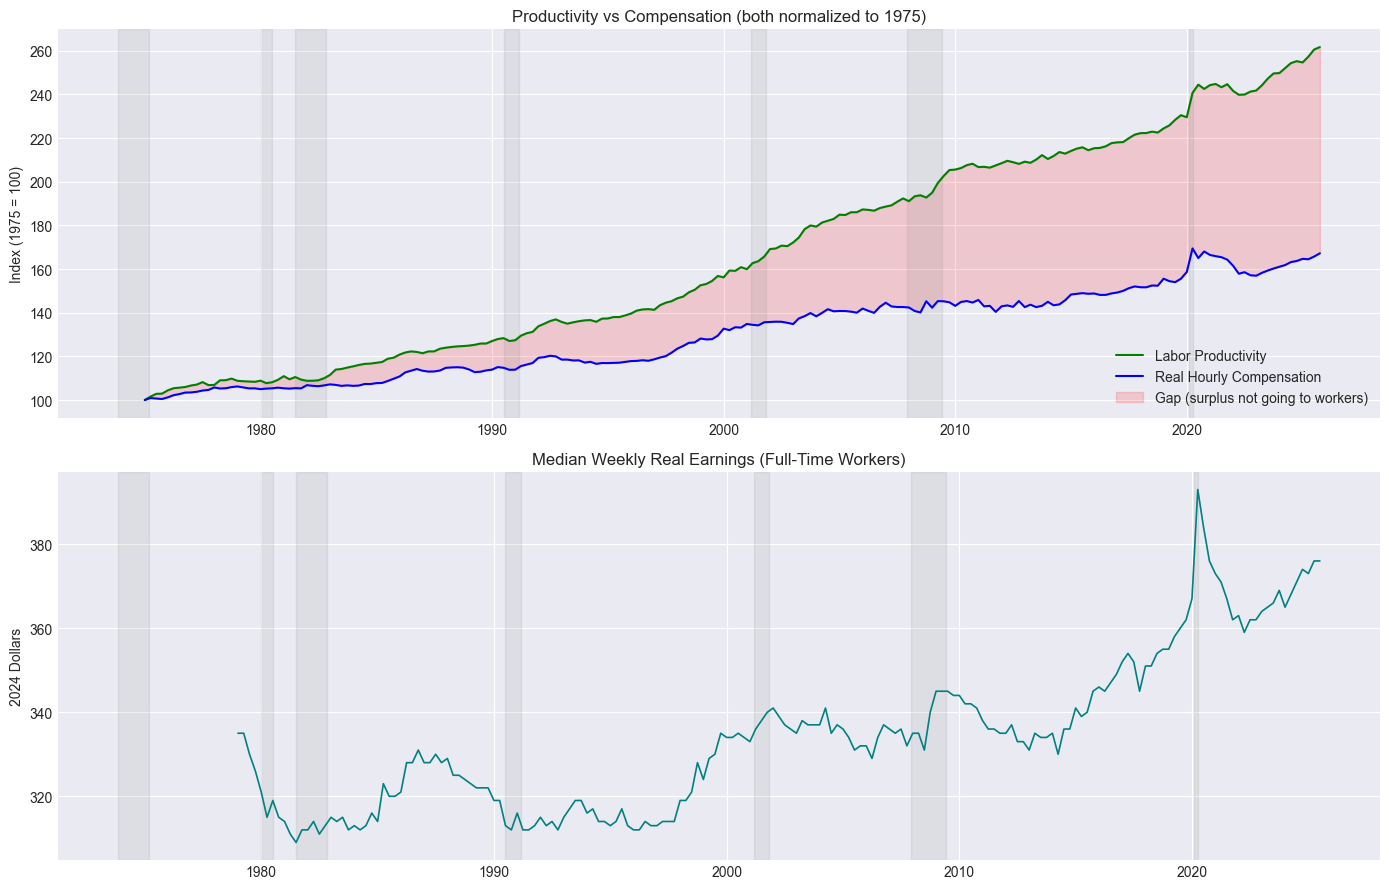


Productivity grew 262% since 1975
Compensation grew 167% since 1975
Gap: 95 index points


In [3]:
productivity = load_series('fred', 'OPHNFB').squeeze()
compensation = load_series('fred', 'COMPRNFB').squeeze()
median_earnings = load_series('fred', 'LES1252881600Q').squeeze()

# Normalize to 100 at 1975
prod_norm = productivity / productivity.iloc[0] * 100
comp_norm = compensation / compensation.iloc[0] * 100

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 9))

ax1.plot(prod_norm.index, prod_norm, color='green', linewidth=1.5, label='Labor Productivity')
ax1.plot(comp_norm.index, comp_norm, color='blue', linewidth=1.5, label='Real Hourly Compensation')
ax1.fill_between(prod_norm.index, prod_norm, comp_norm, alpha=0.15, color='red',
                 where=prod_norm > comp_norm, label='Gap (surplus not going to workers)')
add_recessions(ax1)
ax1.set_ylabel('Index (1975 = 100)')
ax1.set_title('Productivity vs Compensation (both normalized to 1975)')
ax1.legend()

# Median real weekly earnings — the lived experience
ax2.plot(median_earnings.index, median_earnings, color='teal', linewidth=1.2)
add_recessions(ax2)
ax2.set_ylabel('2024 Dollars')
ax2.set_title('Median Weekly Real Earnings (Full-Time Workers)')

plt.tight_layout()
plt.show()

gap = prod_norm.iloc[-1] - comp_norm.iloc[-1]
print(f'\nProductivity grew {prod_norm.iloc[-1]:.0f}% since 1975')
print(f'Compensation grew {comp_norm.iloc[-1]:.0f}% since 1975')
print(f'Gap: {gap:.0f} index points')

## 3. Governance & Policy Uncertainty

The Baker-Bloom-Davis Economic Policy Uncertainty Index, based on newspaper coverage,
captures how unpredictable government economic policy is perceived to be. Rising
uncertainty correlates with institutional dysfunction and political instability.

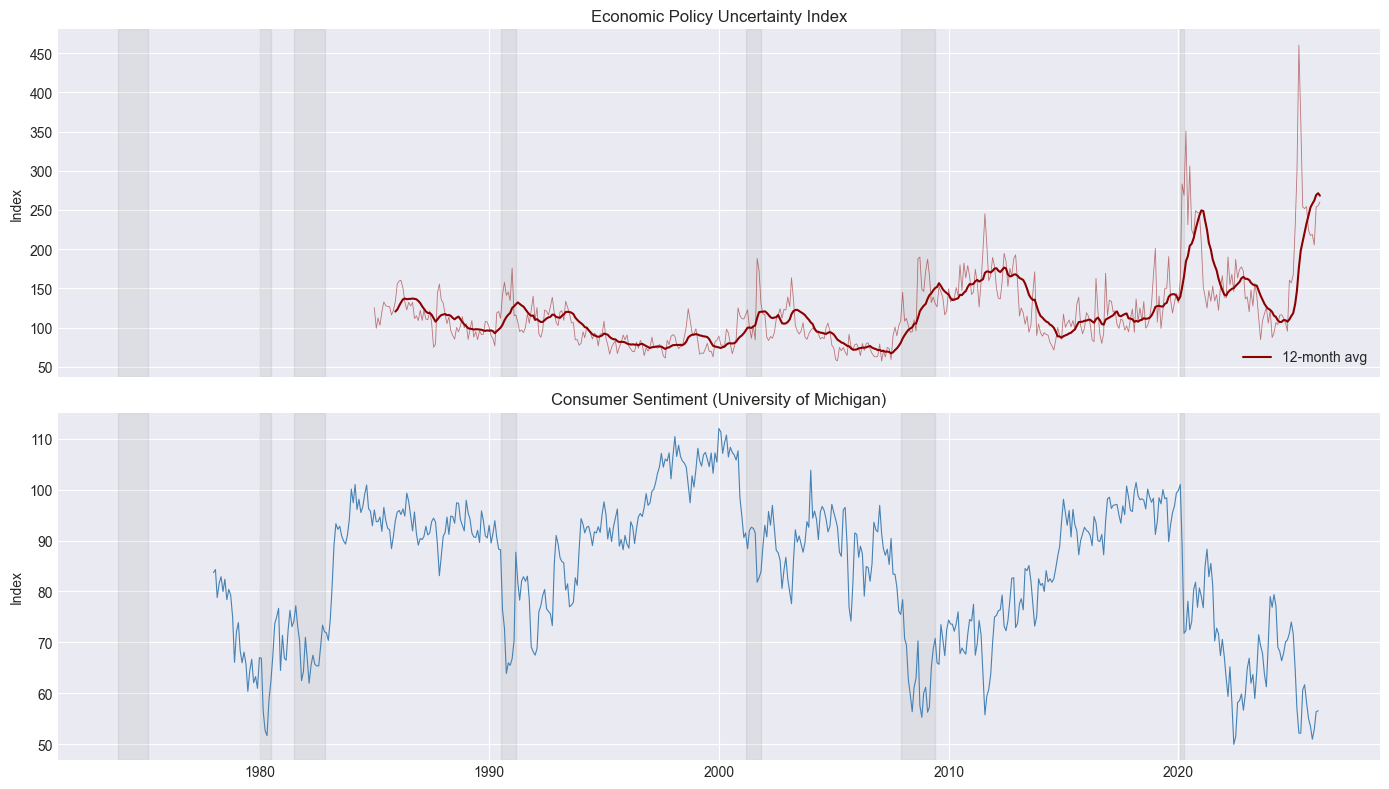


Correlation (EPU 12m avg vs Consumer Sentiment): -0.603
EPU average: 114 (first 5 years) → 167 (last 5 years)


/var/folders/ht/8j5223dn0kjcsdchf0d9k4t00000gn/T/ipykernel_16796/1170772868.py:25: Pandas4Warning: Sorting by default when concatenating all DatetimeIndex is deprecated.  In the future, pandas will respect the default of `sort=False`. Specify `sort=True` or `sort=False` to silence this message. If you see this warnings when not directly calling concat, report a bug to pandas.
  aligned = pd.concat([epu_12m, sentiment], axis=1).dropna()


In [4]:
epu = load_series('fred', 'USEPUINDXM').squeeze()
sentiment = load_series('fred', 'UMCSENT').squeeze()

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

# EPU
ax1.plot(epu.index, epu, color='darkred', linewidth=0.6, alpha=0.5)
epu_12m = epu.rolling(12).mean()
ax1.plot(epu_12m.index, epu_12m, color='darkred', linewidth=1.5, label='12-month avg')
add_recessions(ax1)
ax1.set_ylabel('Index')
ax1.set_title('Economic Policy Uncertainty Index')
ax1.legend()

# Consumer sentiment (inverse relationship expected)
ax2.plot(sentiment.index, sentiment, color='steelblue', linewidth=0.8)
add_recessions(ax2)
ax2.set_ylabel('Index')
ax2.set_title('Consumer Sentiment (University of Michigan)')

plt.tight_layout()
plt.show()

# Correlation
aligned = pd.concat([epu_12m, sentiment], axis=1).dropna()
aligned.columns = ['EPU_12m', 'Sentiment']
corr = aligned['EPU_12m'].corr(aligned['Sentiment'])
print(f'\nCorrelation (EPU 12m avg vs Consumer Sentiment): {corr:.3f}')
print(f'EPU average: {epu.iloc[:60].mean():.0f} (first 5 years) → {epu.iloc[-60:].mean():.0f} (last 5 years)')

## 4. Fiscal Sustainability: The Debt Spiral Question

Interest payments as % of GDP is a key early-warning for fiscal crises. When the
government spends more on debt service, it has less room for everything else. Combined
with rising deficits, this can become self-reinforcing.

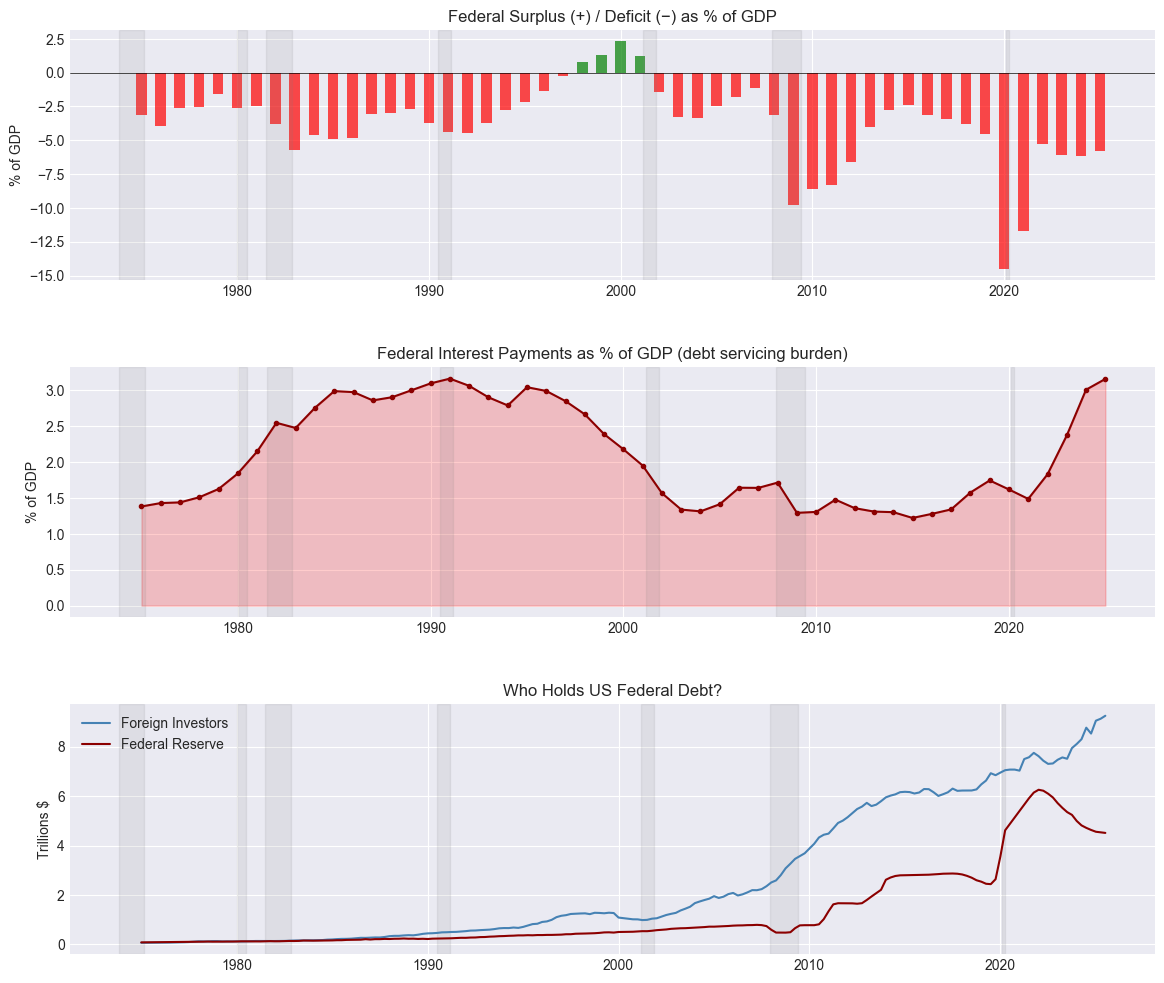


Interest payments: 1.4% GDP (1975) → 3.2% GDP (2025)
Deficit: -5.8% GDP (latest)


In [5]:
deficit_gdp = load_series('fred', 'FYFSGDA188S').squeeze()
interest_gdp = load_series('fred', 'FYOIGDA188S').squeeze()
debt_foreign = load_series('fred', 'FDHBFIN').squeeze()
debt_fed = load_series('fred', 'FDHBFRBN').squeeze()

fig = plt.figure(figsize=(14, 12))
gs = GridSpec(3, 1, figure=fig, hspace=0.35)

# Deficit
ax1 = fig.add_subplot(gs[0])
colors_deficit = np.where(deficit_gdp < 0, 'red', 'green')
ax1.bar(deficit_gdp.index, deficit_gdp, width=200, color=colors_deficit, alpha=0.7)
ax1.axhline(0, color='black', linewidth=0.5)
add_recessions(ax1)
ax1.set_ylabel('% of GDP')
ax1.set_title('Federal Surplus (+) / Deficit (−) as % of GDP')

# Interest payments
ax2 = fig.add_subplot(gs[1])
ax2.plot(interest_gdp.index, interest_gdp, color='darkred', linewidth=1.5, marker='o', markersize=3)
ax2.fill_between(interest_gdp.index, interest_gdp, alpha=0.2, color='red')
add_recessions(ax2)
ax2.set_ylabel('% of GDP')
ax2.set_title('Federal Interest Payments as % of GDP (debt servicing burden)')

# Who holds the debt?
ax3 = fig.add_subplot(gs[2])
# Align to common dates
aligned = pd.concat([debt_foreign, debt_fed], axis=1).dropna()
aligned.columns = ['Foreign Investors', 'Federal Reserve']
# Convert to trillions
aligned = aligned / 1000
ax3.plot(aligned.index, aligned['Foreign Investors'], color='steelblue', linewidth=1.5,
         label='Foreign Investors')
ax3.plot(aligned.index, aligned['Federal Reserve'], color='darkred', linewidth=1.5,
         label='Federal Reserve')
add_recessions(ax3)
ax3.set_ylabel('Trillions $')
ax3.set_title('Who Holds US Federal Debt?')
ax3.legend()

plt.show()

print(f'\nInterest payments: {interest_gdp.iloc[0]:.1f}% GDP ({int(interest_gdp.index[0].year)}) → {interest_gdp.iloc[-1]:.1f}% GDP ({int(interest_gdp.index[-1].year)})')
print(f'Deficit: {deficit_gdp.iloc[-1]:.1f}% GDP (latest)')

## 5. External Order: America's Global Position

The US shifted from the world's largest creditor to its largest debtor. The net
international investment position, current account, and reserve holdings tell the
story of relative decline (or at least of living beyond means).

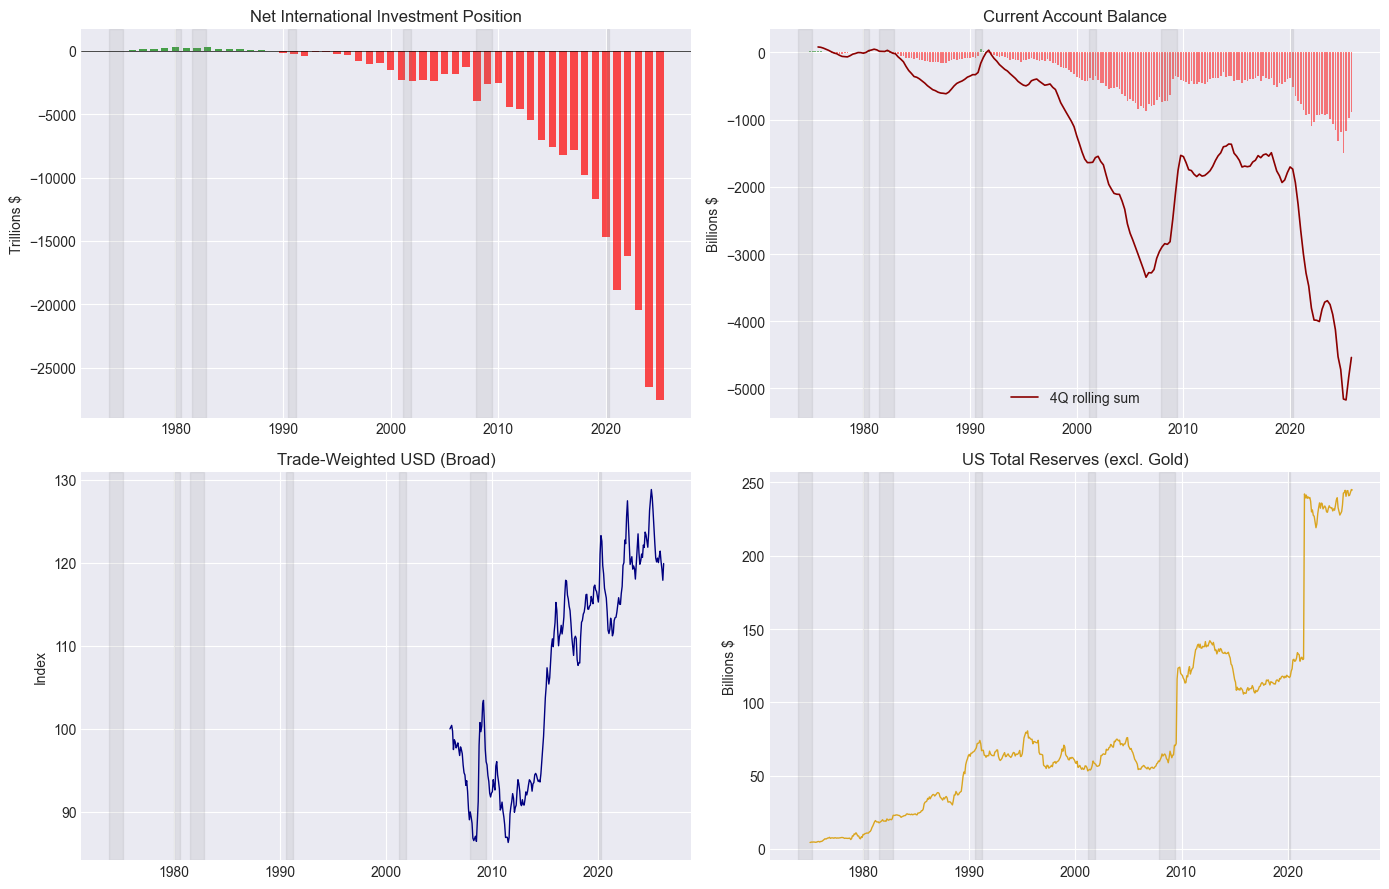


NIIP: $80.5T (1976) → $-27537.0T (2025)
US went from net creditor to net debtor around ~1988


In [6]:
niip = load_series('fred', 'IIPUSNETIA').squeeze()
current_acct = load_series('fred', 'NETFI').squeeze()
usd_tw = load_series('fred', 'TWEXBGSMTH').squeeze()
reserves = load_series('fred', 'TRESEGUSM052N').squeeze()

fig, axes = plt.subplots(2, 2, figsize=(14, 9))

# NIIP
ax = axes[0, 0]
niip_t = niip / 1000  # to trillions
bar_colors = np.where(niip_t < 0, 'red', 'green')
ax.bar(niip_t.index, niip_t, width=250, color=bar_colors, alpha=0.7)
ax.axhline(0, color='black', linewidth=0.5)
add_recessions(ax)
ax.set_ylabel('Trillions $')
ax.set_title('Net International Investment Position')

# Current account
ax = axes[0, 1]
ca_colors = np.where(current_acct < 0, 'red', 'green')
ax.bar(current_acct.index, current_acct, width=60, color=ca_colors, alpha=0.5)
ca_4q = current_acct.rolling(4).sum()  # annualized
ax.plot(ca_4q.index, ca_4q, color='darkred', linewidth=1.2, label='4Q rolling sum')
add_recessions(ax)
ax.set_ylabel('Billions $')
ax.set_title('Current Account Balance')
ax.legend()

# Trade-weighted USD
ax = axes[1, 0]
ax.plot(usd_tw.index, usd_tw, color='navy', linewidth=1.0)
add_recessions(ax)
ax.set_ylabel('Index')
ax.set_title('Trade-Weighted USD (Broad)')

# Reserves
ax = axes[1, 1]
reserves_b = reserves / 1000  # millions to billions
ax.plot(reserves_b.index, reserves_b, color='goldenrod', linewidth=1.0)
add_recessions(ax)
ax.set_ylabel('Billions $')
ax.set_title('US Total Reserves (excl. Gold)')

plt.tight_layout()
plt.show()

print(f'\nNIIP: ${niip.iloc[0]/1000:.1f}T ({int(niip.index[0].year)}) → ${niip.iloc[-1]/1000:.1f}T ({int(niip.index[-1].year)})')
print(f'US went from net creditor to net debtor around ~1988')

## 6. Human Capital & Civilizational Health

Life expectancy, R&D investment, and GDP per capita capture whether a society is
investing in its future or consuming its past. The US life expectancy stall/decline
starting ~2015 is a signal that mainstream economic metrics miss.

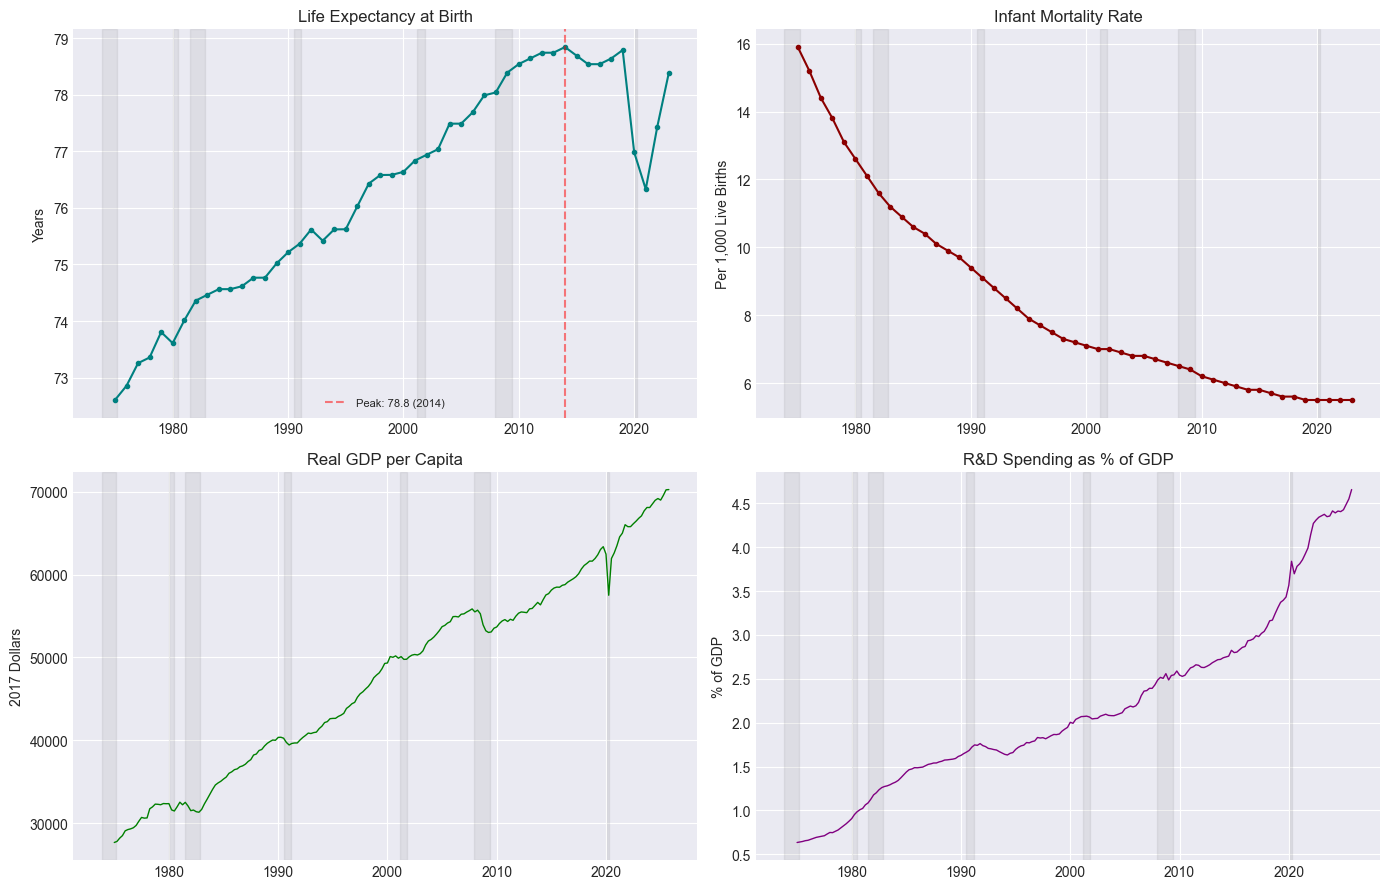


Life expectancy: 72.6 (1975) → 78.4 (2023)
Peak was 78.8 in 2014
Infant mortality: 15.9 → 5.5 per 1,000


In [7]:
life_exp = load_series('fred', 'SPDYNLE00INUSA').squeeze()
infant_mort = load_series('fred', 'SPDYNIMRTINUSA').squeeze()
gdp_pc = load_series('fred', 'A939RX0Q048SBEA').squeeze()
rnd = load_series('fred', 'Y694RC1Q027SBEA').squeeze()

fig, axes = plt.subplots(2, 2, figsize=(14, 9))

# Life expectancy
ax = axes[0, 0]
ax.plot(life_exp.index, life_exp, color='teal', linewidth=1.5, marker='o', markersize=3)
# Highlight the decline
peak_idx = life_exp.idxmax()
ax.axvline(peak_idx, color='red', linestyle='--', alpha=0.5, label=f'Peak: {life_exp.max():.1f} ({peak_idx.year})')
add_recessions(ax)
ax.set_ylabel('Years')
ax.set_title('Life Expectancy at Birth')
ax.legend(fontsize=8)

# Infant mortality
ax = axes[0, 1]
ax.plot(infant_mort.index, infant_mort, color='darkred', linewidth=1.5, marker='o', markersize=3)
add_recessions(ax)
ax.set_ylabel('Per 1,000 Live Births')
ax.set_title('Infant Mortality Rate')

# Real GDP per capita
ax = axes[1, 0]
ax.plot(gdp_pc.index, gdp_pc, color='green', linewidth=1.0)
add_recessions(ax)
ax.set_ylabel('2017 Dollars')
ax.set_title('Real GDP per Capita')

# R&D spending
ax = axes[1, 1]
# R&D as % of GDP
gdp = load_series('fred', 'GDPC1').squeeze()
rnd_pct = (rnd / gdp * 100).dropna()
ax.plot(rnd_pct.index, rnd_pct, color='purple', linewidth=1.0)
add_recessions(ax)
ax.set_ylabel('% of GDP')
ax.set_title('R&D Spending as % of GDP')

plt.tight_layout()
plt.show()

print(f'\nLife expectancy: {life_exp.iloc[0]:.1f} ({int(life_exp.index[0].year)}) → {life_exp.iloc[-1]:.1f} ({int(life_exp.index[-1].year)})')
print(f'Peak was {life_exp.max():.1f} in {life_exp.idxmax().year}')
print(f'Infant mortality: {infant_mort.iloc[0]:.1f} → {infant_mort.iloc[-1]:.1f} per 1,000')

## 7. Debt Monetization: Who's Financing the Deficit?

The shift from foreign financing of US debt to Federal Reserve financing (QE) is
a major structural change. When foreigners stop buying your debt, you print money
to buy it yourself — classic late-stage debt cycle behavior.

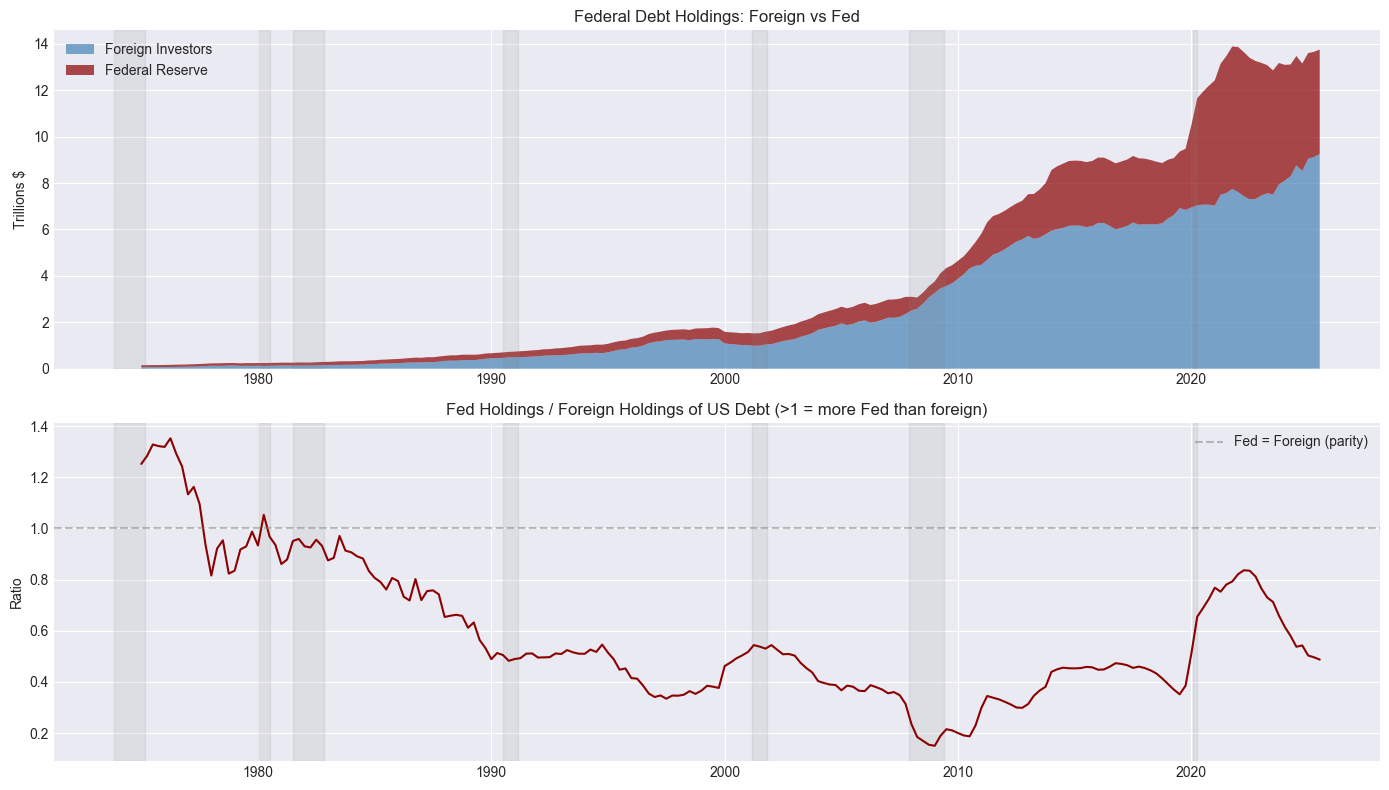

In [8]:
debt_foreign = load_series('fred', 'FDHBFIN').squeeze()
debt_fed = load_series('fred', 'FDHBFRBN').squeeze()
try:
    debt_total_s = load_series('fred', 'GFDEGDQ188S').squeeze()
    has_total = True
except FileNotFoundError:
    has_total = False

# Compute shares
aligned = pd.concat([debt_foreign, debt_fed], axis=1).dropna()
aligned.columns = ['Foreign', 'Fed']
total_held = aligned.sum(axis=1)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8))

# Absolute holdings in trillions
ax1.stackplot(aligned.index, aligned['Foreign']/1000, aligned['Fed']/1000,
              labels=['Foreign Investors', 'Federal Reserve'],
              colors=['steelblue', 'darkred'], alpha=0.7)
add_recessions(ax1)
ax1.set_ylabel('Trillions $')
ax1.set_title('Federal Debt Holdings: Foreign vs Fed')
ax1.legend()

# Ratio: Fed / Foreign
ratio = aligned['Fed'] / aligned['Foreign']
ax2.plot(ratio.index, ratio, color='darkred', linewidth=1.5)
ax2.axhline(1, color='gray', linestyle='--', alpha=0.5, label='Fed = Foreign (parity)')
add_recessions(ax2)
ax2.set_ylabel('Ratio')
ax2.set_title('Fed Holdings / Foreign Holdings of US Debt (>1 = more Fed than foreign)')
ax2.legend()

plt.tight_layout()
plt.show()

## 8. Composite Dashboard: Internal Order Health

Combining inequality, policy uncertainty, fiscal stress, and sentiment into a
single view. Each indicator is z-scored against its own history to make them
comparable.

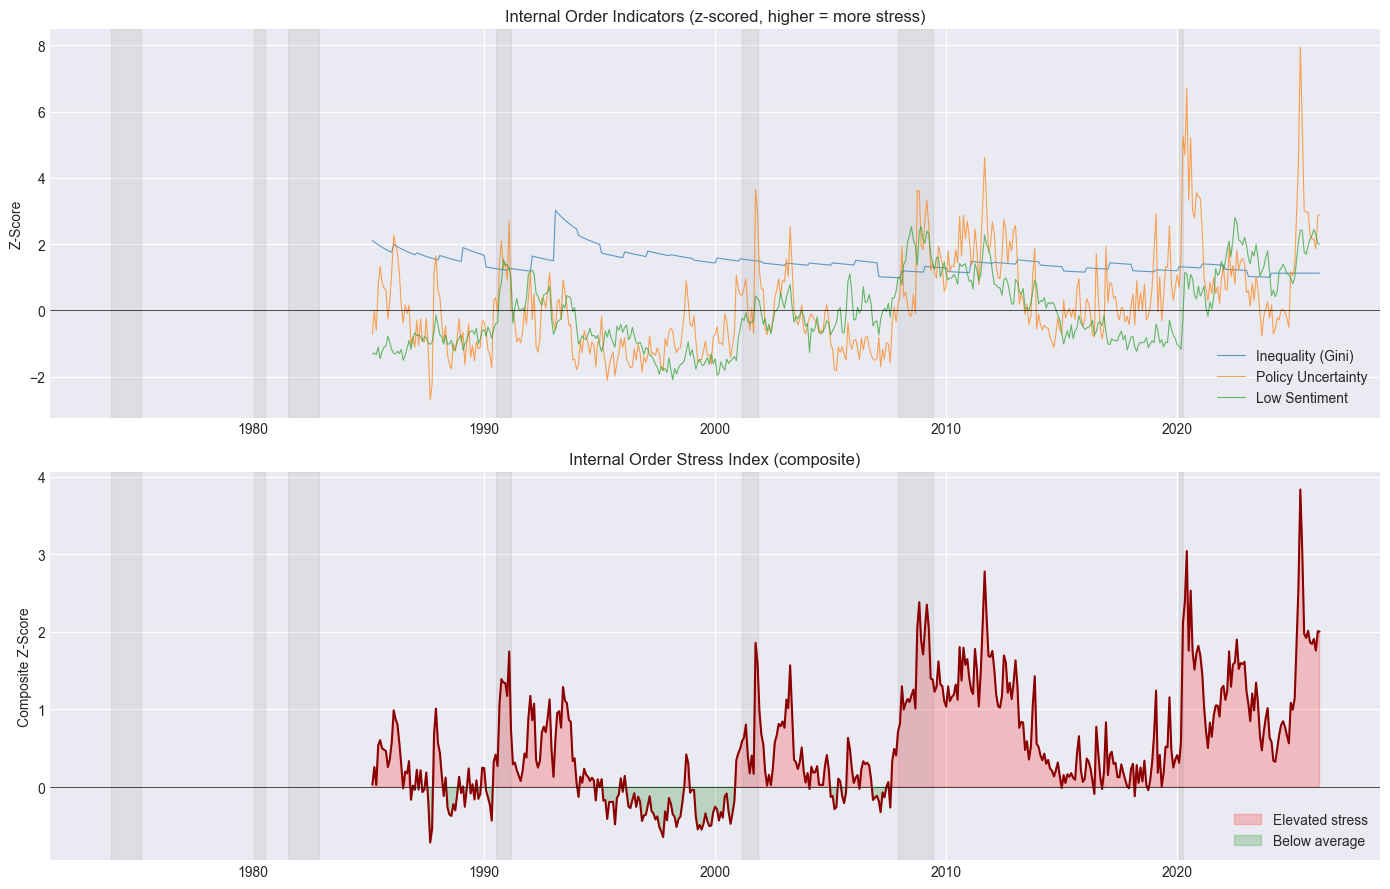


Composite latest: 2.00 (0 = historical average)
Highest stress: 3.83 (2025-04)
Data points: 493


In [9]:
def annual_to_monthly(s):
    """Forward-fill annual data to monthly frequency."""
    return s.resample('ME').ffill()

def zscore_full(s):
    """Z-score against full history (expanding window)."""
    s = s.dropna()
    return (s - s.expanding().mean()) / s.expanding().std()

# Resample everything to month-end for alignment
gini_m = zscore_full(annual_to_monthly(gini))
epu_z = zscore_full(epu.resample('ME').mean())
# Invert sentiment so higher = worse
sentiment_z = zscore_full(-sentiment.resample('ME').last())

# Align on common index
components = pd.DataFrame({
    'Inequality (Gini)': gini_m,
    'Policy Uncertainty': epu_z,
    'Low Sentiment': sentiment_z,
})
# Forward-fill Gini (annual) to fill gaps, then drop any remaining NaN
components['Inequality (Gini)'] = components['Inequality (Gini)'].ffill()
components = components.dropna()

# Composite: simple average of z-scores
composite = components.mean(axis=1)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 9))

# Individual components
for col in components.columns:
    ax1.plot(components.index, components[col], linewidth=0.8, alpha=0.7, label=col)
add_recessions(ax1)
ax1.axhline(0, color='black', linewidth=0.5)
ax1.set_ylabel('Z-Score')
ax1.set_title('Internal Order Indicators (z-scored, higher = more stress)')
ax1.legend()

# Composite
ax2.plot(composite.index, composite, color='darkred', linewidth=1.5)
ax2.fill_between(composite.index, composite, 0,
                 where=composite > 0, alpha=0.2, color='red', label='Elevated stress')
ax2.fill_between(composite.index, composite, 0,
                 where=composite < 0, alpha=0.2, color='green', label='Below average')
add_recessions(ax2)
ax2.axhline(0, color='black', linewidth=0.5)
ax2.set_ylabel('Composite Z-Score')
ax2.set_title('Internal Order Stress Index (composite)')
ax2.legend()

plt.tight_layout()
plt.show()

if len(composite) > 0:
    print(f'\nComposite latest: {composite.iloc[-1]:.2f} (0 = historical average)')
    print(f'Highest stress: {composite.max():.2f} ({composite.idxmax().strftime("%Y-%m")})')
    print(f'Data points: {len(composite)}')

## 9. Cross-Indicator Correlations

Which civilizational indicators move together? This helps us understand which
are truly independent signals vs redundant.

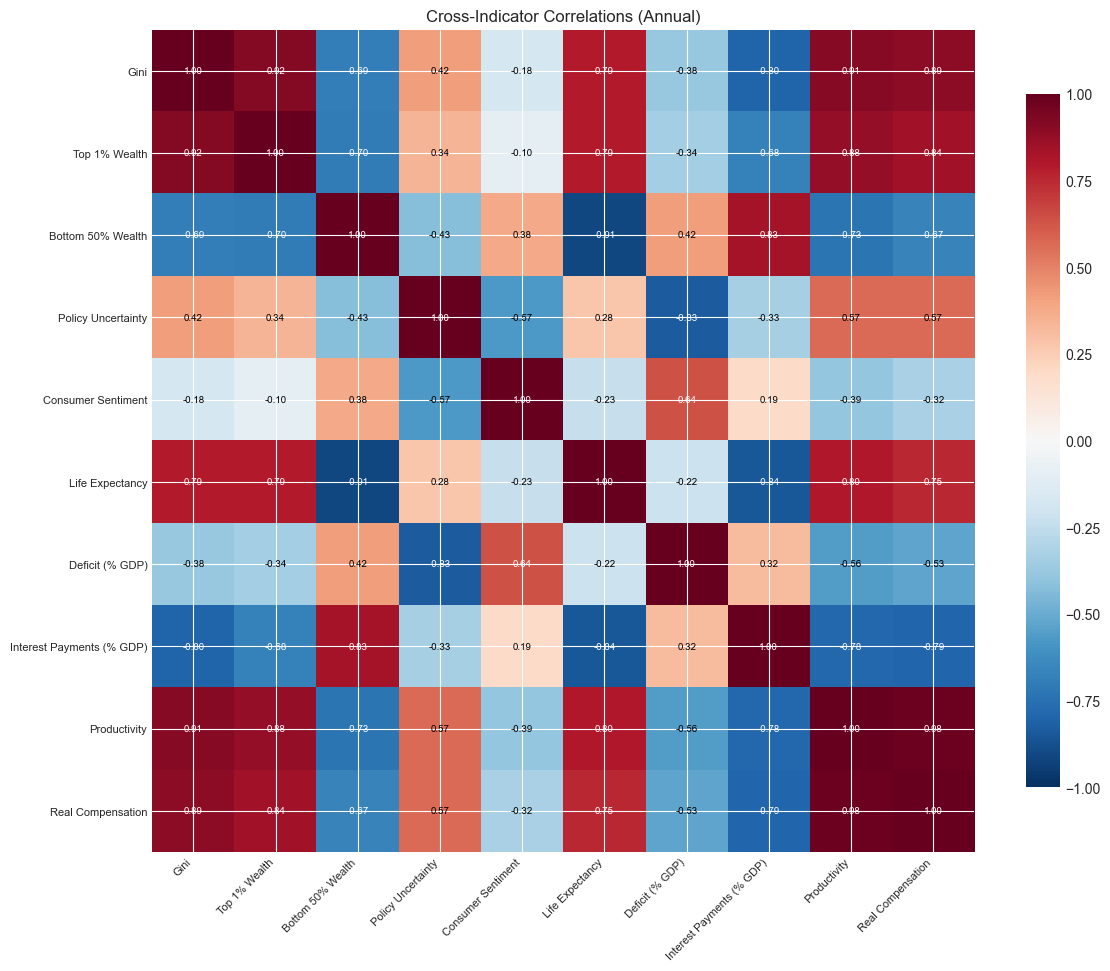

Years of overlap: 35


In [10]:
# Build a wide DataFrame of annual indicators for correlation
# Resample everything to annual for clean comparison
annual_data = pd.DataFrame({
    'Gini': gini.resample('YE').last(),
    'Top 1% Wealth': top1.resample('YE').last(),
    'Bottom 50% Wealth': bottom50.resample('YE').last(),
    'Policy Uncertainty': epu.resample('YE').mean(),
    'Consumer Sentiment': sentiment.resample('YE').mean(),
    'Life Expectancy': life_exp.resample('YE').last(),
    'Deficit (% GDP)': deficit_gdp.resample('YE').last(),
    'Interest Payments (% GDP)': interest_gdp.resample('YE').last(),
    'Productivity': productivity.resample('YE').last(),
    'Real Compensation': compensation.resample('YE').last(),
}).dropna()

corr = annual_data.corr()

fig, ax = plt.subplots(figsize=(12, 10))
im = ax.imshow(corr, cmap='RdBu_r', vmin=-1, vmax=1)
ax.set_xticks(range(len(corr.columns)))
ax.set_yticks(range(len(corr.columns)))
ax.set_xticklabels(corr.columns, rotation=45, ha='right', fontsize=8)
ax.set_yticklabels(corr.columns, fontsize=8)

# Add correlation values
for i in range(len(corr)):
    for j in range(len(corr)):
        ax.text(j, i, f'{corr.iloc[i, j]:.2f}', ha='center', va='center', fontsize=7,
                color='white' if abs(corr.iloc[i, j]) > 0.6 else 'black')

plt.colorbar(im, ax=ax, shrink=0.8)
ax.set_title('Cross-Indicator Correlations (Annual)')
plt.tight_layout()
plt.show()

print(f'Years of overlap: {len(annual_data)}')

## 10. The Big Picture Timeline

Overlaying key civilizational indicators with S&P 500 performance to see how
these slow-moving forces relate to asset returns over the full 1975–present window.

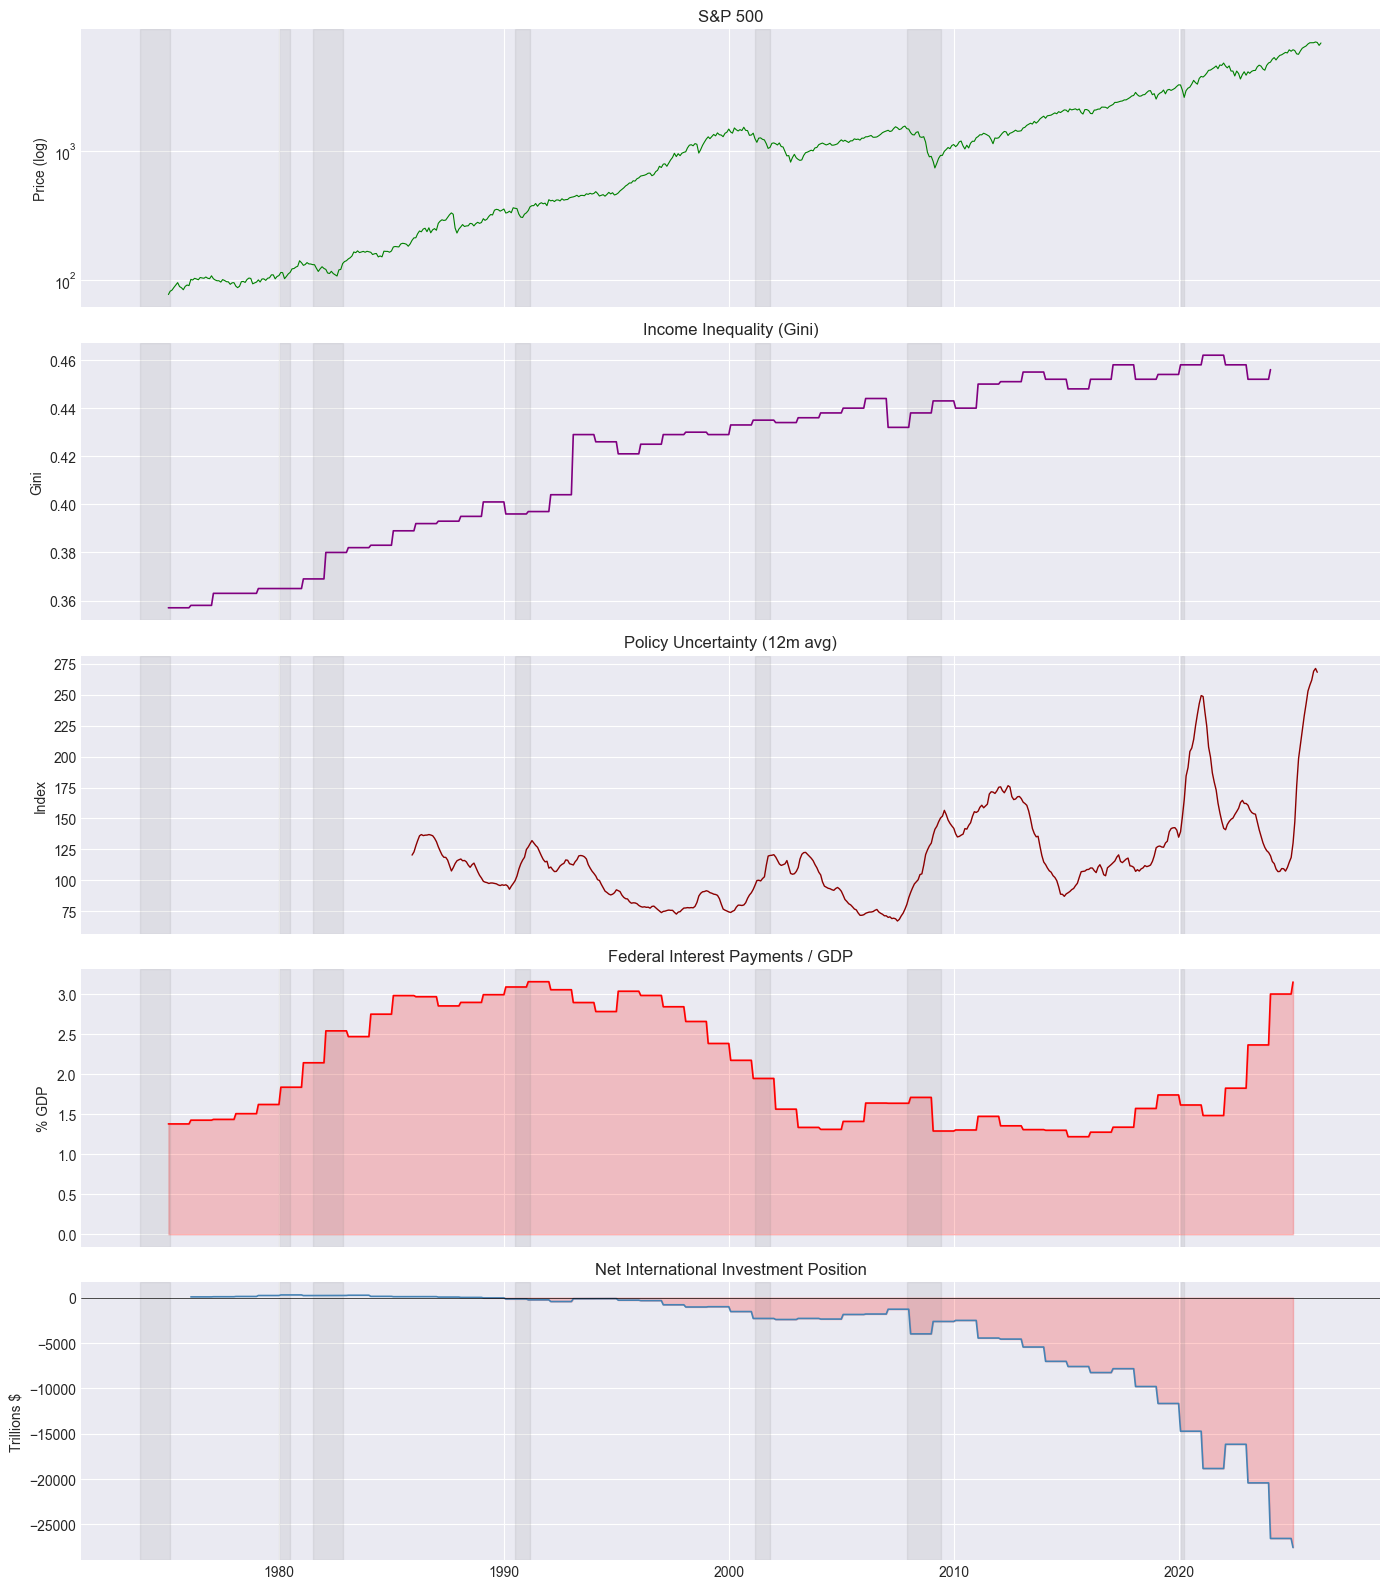

In [11]:
sp500 = load_series('yahoo', '^GSPC')['Close'].resample('ME').last()

def ffill_annual(s):
    """Forward-fill annual data to monthly."""
    return s.resample('ME').ffill()

fig, axes = plt.subplots(5, 1, figsize=(14, 16), sharex=True)

# S&P 500
axes[0].semilogy(sp500.index, sp500, color='green', linewidth=0.8)
add_recessions(axes[0])
axes[0].set_ylabel('Price (log)')
axes[0].set_title('S&P 500')

# Gini
gini_filled = ffill_annual(gini)
axes[1].plot(gini_filled.index, gini_filled, color='purple', linewidth=1.2)
add_recessions(axes[1])
axes[1].set_ylabel('Gini')
axes[1].set_title('Income Inequality (Gini)')

# Policy Uncertainty
epu_12 = epu.rolling(12).mean()
axes[2].plot(epu_12.index, epu_12, color='darkred', linewidth=1.0)
add_recessions(axes[2])
axes[2].set_ylabel('Index')
axes[2].set_title('Policy Uncertainty (12m avg)')

# Interest burden
int_filled = ffill_annual(interest_gdp)
axes[3].plot(int_filled.index, int_filled, color='red', linewidth=1.2)
axes[3].fill_between(int_filled.index, int_filled, alpha=0.2, color='red')
add_recessions(axes[3])
axes[3].set_ylabel('% GDP')
axes[3].set_title('Federal Interest Payments / GDP')

# NIIP
niip_filled = ffill_annual(niip / 1000)
axes[4].plot(niip_filled.index, niip_filled, color='steelblue', linewidth=1.2)
axes[4].fill_between(niip_filled.index, niip_filled, 0,
                     where=niip_filled < 0, alpha=0.2, color='red')
axes[4].axhline(0, color='black', linewidth=0.5)
add_recessions(axes[4])
axes[4].set_ylabel('Trillions $')
axes[4].set_title('Net International Investment Position')

plt.tight_layout()
plt.show()